# **Análisis Exploratorio de Datos (EDA) - Numéricas**

En esta sección se realiza un análisis exploratorio detallado del dataset de Lending Club para las variables numéricas. El objetivo es comprender la estructura de los datos, identificar patrones relevantes y detectar problemas que puedan afectar el modelado, como valores faltantes, outliers o desbalance de clases.

Iniciamos cargando el dataset y generando nuestra variable default como se observó en la sección anterior:

In [21]:
import time
import pandas as pd
from pathlib import Path

DATA_PATH = Path(r"C:\Users\Daniel Rangel\Documents\MachineLearning\Data\accepted_2007_to_2018Q4.csv.gz")

start_time = time.time()

df = pd.read_csv(DATA_PATH, low_memory=False)
df["default"] = df["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)

Y comprobamos la lectura correcta del dataset:

In [22]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,default
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 152 entries, id to default
dtypes: float64(113), int64(1), object(38)
memory usage: 2.6+ GB


In [24]:

df.dtypes.value_counts()

float64    113
object      38
int64        1
dtype: int64

## **Análisis unidimensional**

En esta sección se realiza el análisis unidimensional de las variables del dataset, con el objetivo de entender su comportamiento individual.

Para ello, se separan las variables según su tipo en:
- variables numéricas
- variables categóricas


Esta distinción permitirá aplicar técnicas de análisis apropiadas para cada tipo de variable en las siguientes subsecciones.

In [25]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numéricas:", len(numeric_cols))
print("Categóricas:", len(categorical_cols))

Numéricas: 114
Categóricas: 38


Se identificaron un total de **114 variables numéricas** y **38 variables categóricas** en el dataset.

Esta distribución refleja una predominancia de variables numéricas, como el ingreso anual, el valor del préstamo, etc.

### **Variables Númericas**

Dado el elevado número de variables, el análisis exploratorio se realizará de manera estructurada. En primer lugar, se evaluará la proporción de valores faltantes en cada variable numérica, con el fin de identificar posibles problemas de calidad de datos y definir un criterio para su tratamiento.

Posteriormente, con base en el porcentaje de valores faltantes y en criterios de interpretabilidad y relevancia para el problema de clasificación, se seleccionará un subconjunto representativo de variables para realizar un análisis más detallado.

In [26]:
missing_num = df[numeric_cols].isnull().sum()
missing_pct_num = (missing_num / len(df)) * 100

missing_num_df = pd.DataFrame({
    "missing": missing_num,
    "percentage": missing_pct_num
}).sort_values(by="percentage", ascending=False)

missing_num_df.head(10)

,missing,percentage
member_id,2260701,100.000000
orig_projected_additional_accrued_interest,2252050,99.617331
hardship_payoff_balance_amount,2249784,99.517097
deferral_term,2249784,99.517097
hardship_amount,2249784,99.517097
hardship_dpd,2249784,99.517097
hardship_length,2249784,99.517097
hardship_last_payment_amount,2249784,99.517097
settlement_amount,2226455,98.485160
settlement_percentage,2226455,98.485160


Se identifican múltiples variables con más del 95% de valores faltantes, especialmente aquellas relacionadas con hardship, settlement y second application.

Este comportamiento es debido a que son variables más circunstanciales y no aplican para todos los préstamos, por lo tanto, tienen una baja cobertura en el dataset y no son útiles para el modelado. Con base en el análisis de valores faltantes, se considerará la aplicación de un umbral para la eliminación de variables con alta proporción de datos ausentes.

Como criterio preliminar, se evaluará un umbral del 30% de valores faltantes, bajo el cual las variables podrían ser eliminadas en la etapa de preprocesamiento, ya que su bajo nivel de información disponible limita su utilidad para el modelado.

Así queda la distribución de columnas tras el umbral:

In [35]:
threshold = 30

cols_under_threshold = missing_num_df[
    missing_num_df["percentage"] <= threshold
].index.tolist()

print("Número de variables numéricas con <= 30% de missing:", len(cols_under_threshold))
cols_under_threshold[:20]

Número de variables numéricas con <= 30% de missing: 70


['mths_since_recent_inq',
 'num_tl_120dpd_2m',
 'mo_sin_old_il_acct',
 'bc_util',
 'percent_bc_gt_75',
 'bc_open_to_buy',
 'mths_since_recent_bc',
 'pct_tl_nvr_dlq',
 'avg_cur_bal',
 'mo_sin_old_rev_tl_op',
 'mo_sin_rcnt_rev_tl_op',
 'num_rev_accts',
 'tot_cur_bal',
 'num_actv_rev_tl',
 'num_bc_tl',
 'num_il_tl',
 'num_op_rev_tl',
 'num_tl_30dpd',
 'num_rev_tl_bal_gt_0',
 'num_accts_ever_120_pd']

Con base en el umbral del 30% de valores faltantes, se identificaron **70 variables numéricas** que cumplen con este criterio de calidad de datos.

Esto implica que aproximadamente el 61% de las variables numéricas presentan cumplen con una cantidad de datos adecuada para su análisis, mientras que el resto presenta proporciones elevadas de valores faltantes. Estas 70 variables constituyen el conjunto base a partir del cual se realizará la selección de variables relevantes para el análisis exploratorio detallado.

Tras la revisión de las 70 variables, se realizó una selección adicional basada en la relevancia para el problema de predicción de default, por lo que, se excluyeron variables que representan información posterior al otorgamiento del préstamo (data leakage), así como variables con baja interpretabilidad o redundancia.

El conjunto final que se presenta a continuación incluye variables relacionadas con el monto del préstamo, capacidad de pago del cliente, nivel de endeudamiento y perfil crediticio, las cuales son consideradas fundamentales en modelos de riesgo crediticio.

In [28]:
num_vars = [
    "loan_amnt",          # monto del préstamo
    "int_rate",           # costo del crédito
    "annual_inc",         # ingresos
    "dti",                # capacidad de pago
    "fico_range_high",    # score crediticio
    "revol_util",         # uso del crédito (muy importante)
    "open_acc",           # número de cuentas
    "total_acc",          # historial crediticio total
   
]

Con estas variables se procede a realizar el análisis estadístico:

In [29]:
df[num_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,2260668.0,15046.931228,9190.245488,500.00,8000.00,12900.00,20000.00,4.000000e+04
int_rate,2260668.0,13.092829,4.832138,5.31,9.49,12.62,15.99,3.099000e+01
annual_inc,2260664.0,77992.428687,112696.199574,0.00,46000.00,65000.00,93000.00,1.100000e+08
dti,2258957.0,18.824196,14.183329,-1.00,11.89,17.84,24.49,9.990000e+02
fico_range_high,2260668.0,702.588400,33.011245,614.00,679.00,694.00,719.00,8.500000e+02
revol_util,2258866.0,50.337696,24.713073,0.00,31.50,50.30,69.40,8.923000e+02
open_acc,2260639.0,11.612402,5.640861,0.00,8.00,11.00,14.00,1.010000e+02
total_acc,2260639.0,24.162552,11.987528,1.00,15.00,22.00,31.00,1.760000e+02


In [30]:
iqr_df = pd.DataFrame({
    "Q1": df[num_vars].quantile(0.25),
    "Q3": df[num_vars].quantile(0.75),
})

iqr_df["IQR"] = iqr_df["Q3"] - iqr_df["Q1"]

iqr_df.sort_values(by="IQR", ascending=False)

,Q1,Q3,IQR
annual_inc,46000.00,93000.00,47000.0
loan_amnt,8000.00,20000.00,12000.0
fico_range_high,679.00,719.00,40.0
revol_util,31.50,69.40,37.9
total_acc,15.00,31.00,16.0
dti,11.89,24.49,12.6
int_rate,9.49,15.99,6.5
open_acc,8.00,14.00,6.0


In [31]:
outliers_data = []

for col in num_vars:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    outliers_data.append({
        "variable": col,
        "outliers": outliers,
        "percentage": (outliers / len(df)) * 100
    })

outliers_df = pd.DataFrame(outliers_data).sort_values(by="percentage", ascending=False)

outliers_df

,variable,outliers,percentage
2,annual_inc,110041,4.867561
6,open_acc,84754,3.749014
4,fico_range_high,74846,3.310743
1,int_rate,41099,1.817976
7,total_acc,39411,1.743309
0,loan_amnt,35215,1.557703
3,dti,21580,0.954571
5,revol_util,114,0.005043


### **Análisis unidimensional de variables numéricas seleccionadas**

Se realizó el análisis unidimensional sobre el conjunto de 8 variables numéricas seleccionadas, considerando criterios de calidad de datos y relevancia para el problema de predicción de default.

#### **Estadísticas descriptivas**

Las estadísticas descriptivas evidencian que las variables relacionadas con el monto del préstamo (`loan_amnt`) presentan una media cercana a 15,000, con un rango entre 500 y 40,000, lo que refleja la variabilidad en los montos otorgados.

La tasa de interés (`int_rate`) presenta una media de aproximadamente 13%, con valores entre 5.31% y 30.99%, indicando diversidad en las condiciones de crédito asignadas a los clientes.

En cuanto a los ingresos (`annual_inc`), se observa una media cercana a 78,000, pero con una desviación estándar elevada y un valor máximo extremadamente alto (1.1e+08), lo cual sugiere una distribución fuertemente sesgada y la presencia de valores atípicos.

La variable `dti` presenta valores extremos (hasta 999), lo cual no es típico y sugiere posibles anomalías o valores atípicos significativos.


#### **Análisis del rango intercuartílico (IQR)**

El análisis del IQR muestra que variables como `annual_inc` y `loan_amnt` presentan una alta dispersión, reflejando la heterogeneidad de los perfiles financieros.

Variables como `fico_range_high` presentan una dispersión moderada, lo cual es consistente con la naturaleza de los puntajes crediticios, que suelen mantenerse en rangos específicos.


#### **Detección de valores atípicos**

La detección de valores atípicos mediante el método del IQR muestra que:

- `annual_inc` presenta aproximadamente un 4.87% de outliers, lo cual es esperado en variables económicas debido a distribuciones con colas largas.
- Variables como `open_acc` y `fico_range_high` presentan entre 3% y 4% de valores atípicos.
- Variables como `loan_amnt` e `int_rate` presentan una proporción moderada de outliers (alrededor del 1%–2%).
- `revol_util` presenta una proporción mínima de valores atípicos, indicando una distribución relativamente estable.

En general, la presencia de outliers es consistente con la naturaleza de los datos financieros, donde es común encontrar valores extremos en variables relacionadas con ingresos, endeudamiento y comportamiento crediticio.

#### **Conclusión del análisis**

El análisis unidimensional de las variables numéricas permite concluir que:

- Se presentan valores atípicos significativos en varias variables.
- Algunas variables muestran alta concentración en valores específicos (principalmente cero).
- La variabilidad observada refleja la diversidad de perfiles financieros en el dataset.

#### **Histogramas**

Para una mejor comprensión visual se desarrollaron los siguientes histogramas por variable:

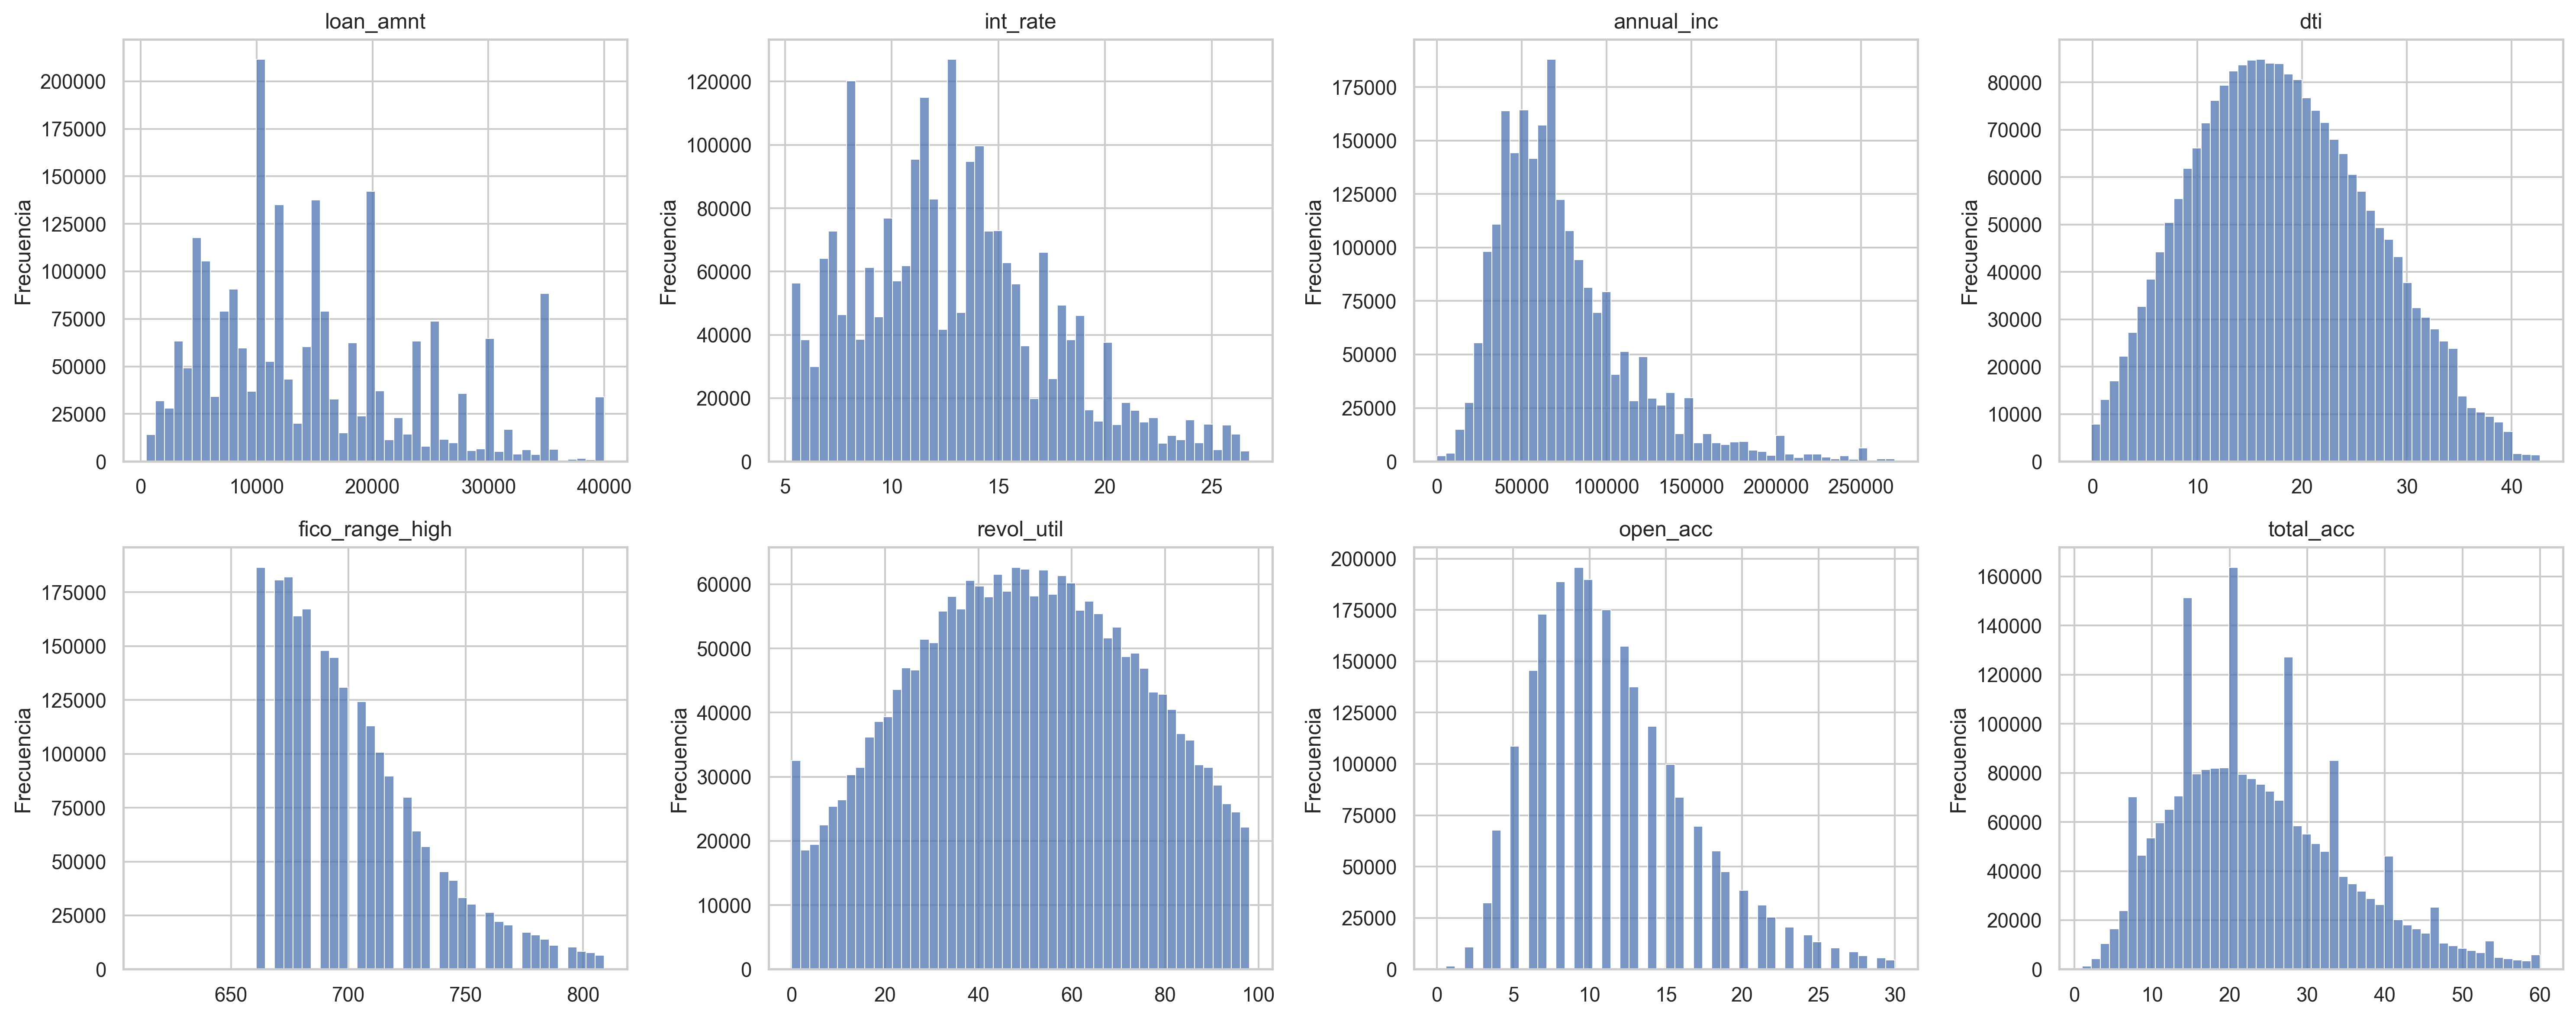

In [32]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 4, figsize=(20, 8), dpi=300)
axes = axes.flatten()

for i, col in enumerate(num_vars):
    data = df[col].dropna()
    
    upper_limit = data.quantile(0.99)
    data = data[data <= upper_limit]
    
    sns.histplot(data, bins=50, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

#### **Diagramas de caja de variables numéricas**

A continuación se presentan diagramas de caja para las variables numéricas seleccionadas, con el fin de identificar asimetría y presencia de valores atípicos mediante inspección visual.

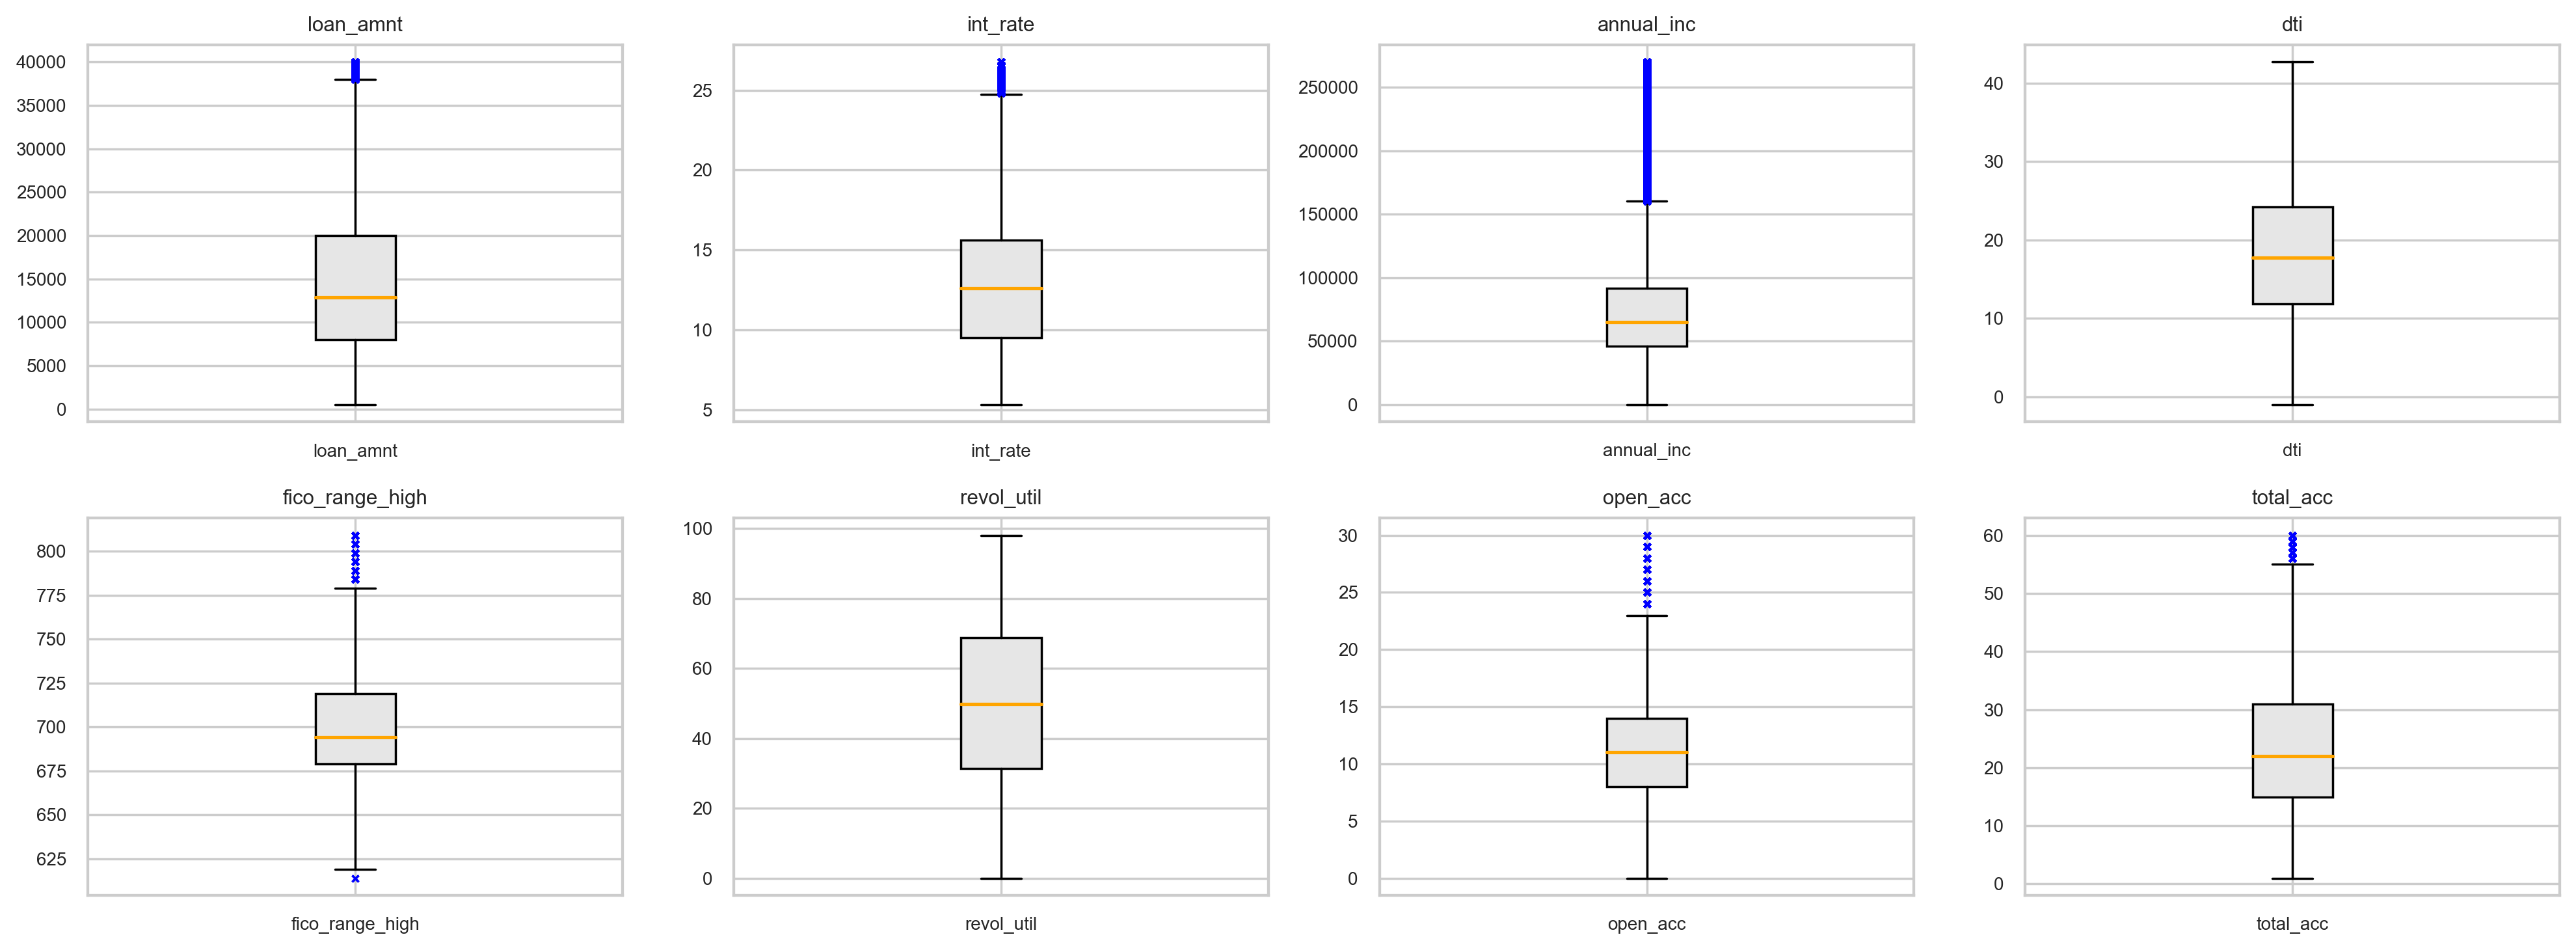

In [33]:
import math
import matplotlib.pyplot as plt

ncols = 4
nrows = math.ceil(len(num_vars) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6), dpi=250)
axes = axes.flatten()

for i, col in enumerate(num_vars):
    data = df[col].dropna()
    upper = data.quantile(0.99)
    data_vis = data[data <= upper]

    axes[i].boxplot(
        data_vis,
        vert=True,
        patch_artist=True,
        labels=[col],
        boxprops=dict(facecolor="#e6e6e6", edgecolor="black"),
        medianprops=dict(color="orange", linewidth=1.5),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        flierprops=dict(
            marker="x",
            markeredgecolor="blue",
            markersize=3,
            linestyle="none"
        )
    )

    axes[i].set_title(f"{col}", fontsize=9)
    axes[i].tick_params(axis="x", labelsize=8)
    axes[i].tick_params(axis="y", labelsize=8)

for j in range(len(num_vars), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

En variables con valores extremos muy elevados, la visualización puede complementarse con una versión recortada al percentil 99 únicamente con fines gráficos, sin modificar el análisis estadístico realizado sobre los datos originales.

#### **Evaluación de normalidad de las variables numéricas**

Dado el gran tamaño del dataset, la normalidad de las variables numéricas se evaluará mediante el coeficiente de asimetría (*skewness*), en lugar de aplicar pruebas como Shapiro-Wilk, que no resultan prácticas en conjuntos de datos de esta magnitud.

Este análisis permitirá identificar variables con distribuciones sesgadas y valorar la posible necesidad de aplicar transformaciones en etapas posteriores del proyecto.

In [34]:
skew_df = pd.DataFrame({
    "skewness": df[num_vars].skew()
})

skew_df["abs_skewness"] = skew_df["skewness"].abs()

def classify_skew(x):
    if x < 0.5:
        return "baja"
    elif x < 1:
        return "moderada"
    else:
        return "alta"

skew_df["nivel_asimetria"] = skew_df["abs_skewness"].apply(classify_skew)

skew_df.sort_values(by="abs_skewness", ascending=False)

,skewness,abs_skewness,nivel_asimetria
annual_inc,493.886088,493.886088,alta
dti,29.201854,29.201854,alta
open_acc,1.315545,1.315545,alta
fico_range_high,1.193116,1.193116,alta
total_acc,1.007456,1.007456,alta
loan_amnt,0.777782,0.777782,moderada
int_rate,0.768071,0.768071,moderada
revol_util,0.012556,0.012556,baja


#### **Interpretación de la asimetría de las variables numéricas**

El análisis de asimetría muestra que la mayoría de las variables numéricas seleccionadas no sigue una distribución normal.

En particular, `annual_inc` presenta una asimetría extremadamente alta, lo cual indica una distribución fuertemente sesgada hacia la derecha, consistente con la presencia de ingresos excepcionalmente altos. De manera similar, `dti` también presenta una asimetría muy elevada, lo que sugiere la existencia de valores extremos y una fuerte concentración de observaciones en rangos bajos o medios.

Las variables `open_acc`, `fico_range_high` y `total_acc` presentan asimetría alta, aunque en menor magnitud, mientras que `loan_amnt` e `int_rate` presentan una asimetría moderada. Por otro lado, `revol_util` muestra una asimetría baja, lo que indica una distribución relativamente más equilibrada.

En conjunto, estos resultados sugieren que no se cumple el supuesto de normalidad en varias de las variables analizadas, lo cual es frecuente en datasets financieros.

Por lo tanto, en etapas posteriores podría evaluarse la aplicación de transformaciones en variables altamente sesgadas, especialmente `annual_inc`.